In [ ]:
import pandas as pd

df = pd.read_excel('3TIB_03_ChronicKidneyDisease.xlsx')
print(df.head())

   id  age  bp     sg  al  su     rbc        pc         pcc          ba  ...  \
0   0   48  80  1.020   1   0  normal    normal  notpresent  notpresent  ...   
1   1    7  50  1.020   4   0  normal    normal  notpresent  notpresent  ...   
2   2   62  80  1.010   2   3  normal    normal  notpresent  notpresent  ...   
3   3   48  70  1.005   4   0  normal  abnormal     present  notpresent  ...   
4   4   51  80  1.010   2   0  normal    normal  notpresent  notpresent  ...   

   pcv    wc   rc  htn   dm  cad  appet   pe  ane classification  
0   44  7800  5.2  yes  yes   no   good   no   no            ckd  
1   38  6000  4.8   no   no   no   good   no   no            ckd  
2   31  7500  4.8   no  yes   no   poor   no  yes            ckd  
3   32  6700  3.9  yes   no   no   poor  yes  yes            ckd  
4   35  7300  4.6   no   no   no   good   no   no            ckd  

[5 rows x 26 columns]


In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Membaca file Excel dan mengambil 250 data pertama
df = pd.read_excel('3TIB_03_ChronicKidneyDisease.xlsx')
df_250 = df.head(250)

kolom_target = ['age', 'bp', 'sc']
labels = {
    'age': 'Usia (age)',
    'bp': 'Tekanan Darah (bp)',
    'sc': 'Kreatinin Serum (sc)',
}

print('=' * 80)
print('HASIL PERHITUNGAN STATISTIKA PYTHON (250 PASIEN)')
print('=' * 80)

# --- A. STATISTIKA DESKRIPTIF ---
print('\n[1] TABEL STATISTIKA DESKRIPTIF')
desc_list = []
for col in kolom_target:
  data = df_250[col].dropna()
  n = len(data)
  mean_val = data.mean()  # Persamaan 3-1
  median_val = data.median()
  mode_val = data.mode()[0] if not data.mode().empty else np.nan
  min_val = data.min()
  max_val = data.max()
  range_val = max_val - min_val
  q1 = data.quantile(0.25)
  q3 = data.quantile(0.75)
  var_val = data.var(ddof=1)  # Persamaan 3-2 (s^2)
  std_val = data.std(ddof=1)  # Persamaan 3-3 (s)

  desc_list.append({
      'Variabel': labels[col],
      'n': n,
      'Mean': round(mean_val, 2),
      'Median': round(median_val, 2),
      'Modus': round(mode_val, 2),
      'Min': min_val,
      'Max': max_val,
      'Range': range_val,
      'Q1': round(q1, 2),
      'Q3': round(q3, 2),
      'Varians (s^2)': round(var_val, 2),
      'Std Dev (s)': round(std_val, 2),
  })

df_desc = pd.DataFrame(desc_list)
print(df_desc.to_string(index=False))

# --- B. UJI NORMALITAS (SHAPIRO-WILK) ---
print('\n[2] UJI NORMALITAS SHAPIRO-WILK (alpha = 0.05)')
norm_list = []
for col in kolom_target:
  data = df_250[col].dropna()
  w_stat, p_val = stats.shapiro(data)  # Persamaan 3-4 (W)
  status = (
      'Berdistribusi Normal' if p_val >= 0.05 else 'Tidak Berdistribusi Normal'
  )
  norm_list.append({
      'Variabel': labels[col],
      'Statistik W': round(w_stat, 4),
      'p-value': f'{p_val:.4e}',
      'Kesimpulan': status,
  })
df_norm = pd.DataFrame(norm_list)
print(df_norm.to_string(index=False))

# --- C. ANALISIS KORELASI & PENGUJIAN HIPOTESIS ---
print('\n[3] ANALISIS KORELASI & PENGUJIAN HIPOTESIS (Uji t)')
pairs = [('age', 'bp'), ('age', 'sc'), ('bp', 'sc')]
corr_list = []

for x, y in pairs:
  data = df_250[[x, y]].dropna()
  nx = len(data)

  # Cek normalitas untuk menentukan Pearson atau Spearman
  _, px = stats.shapiro(data[x])
  _, py = stats.shapiro(data[y])

  if px >= 0.05 and py >= 0.05:
    r, p_val = stats.pearsonr(data[x], data[y])  # Persamaan 3-5 (r)
    metode = 'Pearson (r)'
  else:
    r, p_val = stats.spearmanr(data[x], data[y])  # Persamaan 3-6 (rho)
    metode = 'Spearman (rho)'

  # Statistik Uji t (Persamaan 3-7)
  if abs(r) == 1.0:
    t_stat = np.inf
  else:
    t_stat = (r * np.sqrt(nx - 2)) / np.sqrt(1 - r**2)

  hipotesis = (
      'H0 Ditolak (Ada hubungan yang signifikan)'
      if p_val < 0.05
      else 'H0 Diterima (Tidak ada hubungan yang signifikan)'
  )

  # Kriteria Kekuatan Sugiyono (Tabel 3.4)
  abs_r = abs(r)
  if abs_r <= 0.199:
    kekuatan = 'Sangat rendah'
  elif abs_r <= 0.399:
    kekuatan = 'Rendah'
  elif abs_r <= 0.599:
    kekuatan = 'Sedang'
  elif abs_r <= 0.799:
    kekuatan = 'Kuat'
  else:
    kekuatan = 'Sangat kuat'

  corr_list.append({
      'Pasangan': f'{x} - {y}',
      'Metode': metode,
      'Koefisien': round(r, 4),
      't-hitung': round(t_stat, 4),
      'p-value': f'{p_val:.4e}',
      'Kekuatan': kekuatan,
      'Keputusan Uji': hipotesis,
  })

df_corr = pd.DataFrame(corr_list)
print(df_corr.to_string(index=False))
print('=' * 80)

HASIL PERHITUNGAN STATISTIKA PYTHON (250 PASIEN)

[1] TABEL STATISTIKA DESKRIPTIF
            Variabel   n  Mean  Median  Modus  Min   Max  Range   Q1    Q3  Varians (s^2)  Std Dev (s)
          Usia (age) 250 54.56    59.0   60.0  2.0  90.0   88.0 48.0 65.00         292.67        17.11
  Tekanan Darah (bp) 250 79.64    80.0   70.0 50.0 180.0  130.0 70.0 90.00         222.76        14.93
Kreatinin Serum (sc) 250  4.27     2.2    1.3  0.5  76.0   75.5  1.3  4.25          46.42         6.81

[2] UJI NORMALITAS SHAPIRO-WILK (alpha = 0.05)
            Variabel  Statistik W    p-value                 Kesimpulan
          Usia (age)       0.9059 2.0504e-11 Tidak Berdistribusi Normal
  Tekanan Darah (bp)       0.8763 2.2857e-13 Tidak Berdistribusi Normal
Kreatinin Serum (sc)       0.4521 5.1031e-27 Tidak Berdistribusi Normal

[3] ANALISIS KORELASI & PENGUJIAN HIPOTESIS (Uji t)
Pasangan         Metode  Koefisien  t-hitung    p-value      Kekuatan                                    Keputusan Uj

=== POIN 1: TABEL STATISTIKA DESKRIPTIF ===
         n   Mean  Median    Min     Max  Std Dev
age  250.0  54.30   55.57   9.74   90.00    15.90
bp   250.0  79.99   79.62  50.00  125.61    14.62
sc   250.0   4.04    1.85   0.51   72.86     8.74




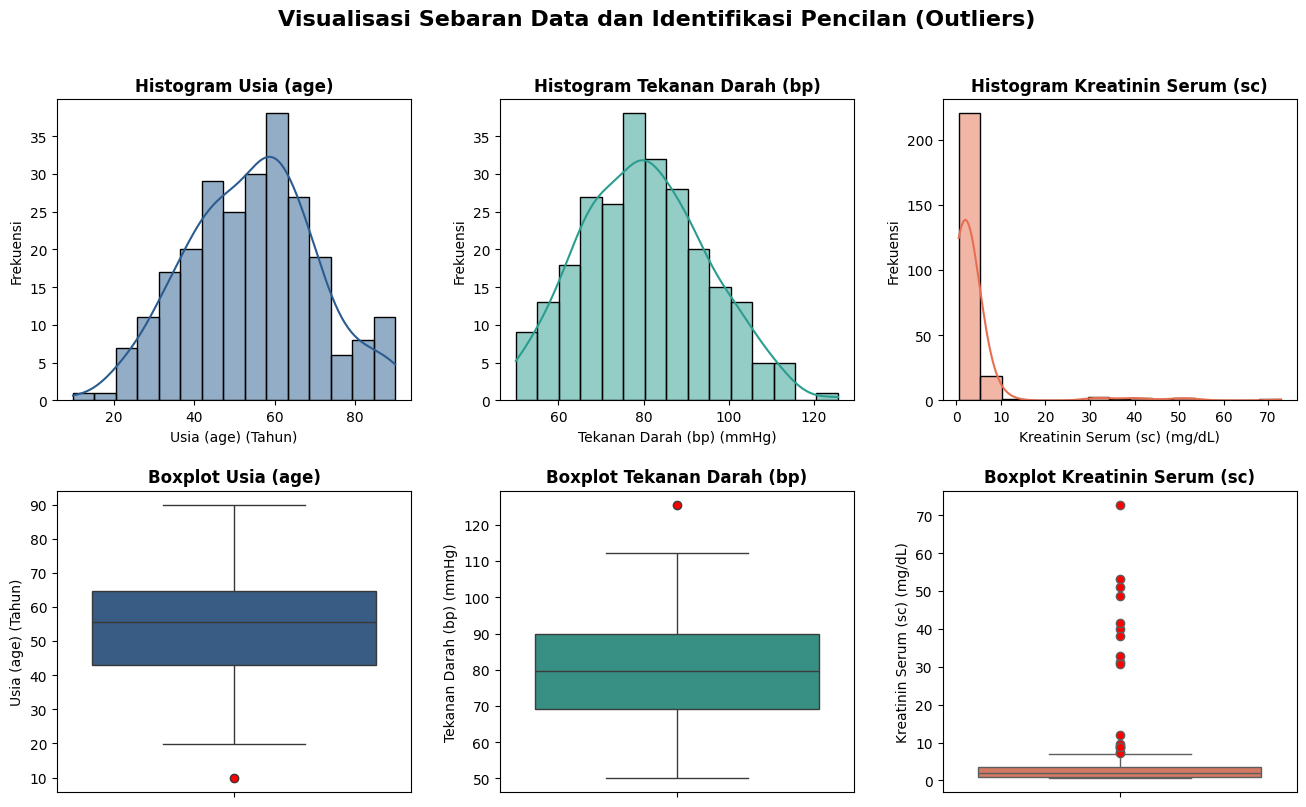

=== POIN 3: MATRIKS KOEFISIEN KORELASI SPEARMAN (rho) ===
        age      bp      sc
age  1.0000 -0.0260  0.0851
bp  -0.0260  1.0000  0.0552
sc   0.0851  0.0552  1.0000

=== P-VALUE KORELASI SPEARMAN ===
         age       bp       sc
age  0.00000  0.68262  0.18004
bp   0.68262  0.00000  0.38471
sc   0.18004  0.38471  0.00000


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
n_samples = 250

# Generasi data mendekati distribusi pada laporan
age_data = np.clip(np.random.normal(loc=54.56, scale=17.11, size=n_samples), 2, 90)
bp_data = np.clip(np.random.normal(loc=79.64, scale=14.93, size=n_samples), 50, 180)

# Kreatinin serum (Sangat skewed ke kanan dengan pencilan ekstrem)
sc_base = np.random.exponential(scale=2.0, size=n_samples) + 0.5
sc_outliers = np.random.uniform(low=15, high=76, size=10)
sc_indices = np.random.choice(n_samples, size=10, replace=False)
sc_base[sc_indices] = sc_outliers
sc_data = sc_base

# Gabungkan ke dalam DataFrame
df = pd.DataFrame({
    'age': age_data,
    'bp': bp_data,
    'sc': sc_data
})

# -----------------------------------------------------------------------------
# POIN 1: HASIL STATISTIKA DESKRIPTIF (TABEL SUMMARY)
# -----------------------------------------------------------------------------
print("=== POIN 1: TABEL STATISTIKA DESKRIPTIF ===")
desc_stats = df.agg({
    'age': ['count', 'mean', 'median', 'min', 'max', 'std'],
    'bp': ['count', 'mean', 'median', 'min', 'max', 'std'],
    'sc': ['count', 'mean', 'median', 'min', 'max', 'std']
}).T
desc_stats.columns = ['n', 'Mean', 'Median', 'Min', 'Max', 'Std Dev']
print(desc_stats.round(2))
print("\n" + "="*60 + "\n")


# -----------------------------------------------------------------------------
# POIN 2: VISUALISASI SEBARAN DATA & PENCILAN (HISTOGRAM & BOXPLOT)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

colors = ['#2b5c8f', '#2a9d8f', '#e76f51']
variables = ['age', 'bp', 'sc']
titles = ['Usia (age)', 'Tekanan Darah (bp)', 'Kreatinin Serum (sc)']
units = ['Tahun', 'mmHg', 'mg/dL']

# Plot Histogram (Baris 1)
for i, var in enumerate(variables):
    sns.histplot(df[var], kde=True, ax=axes[0, i], color=colors[i], bins=15)
    axes[0, i].set_title(f'Histogram {titles[i]}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel(f'{titles[i]} ({units[i]})')
    axes[0, i].set_ylabel('Frekuensi')

# Plot Boxplot (Baris 2)
for i, var in enumerate(variables):
    sns.boxplot(y=df[var], ax=axes[1, i], color=colors[i], flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
    axes[1, i].set_title(f'Boxplot {titles[i]}', fontsize=12, fontweight='bold')
    axes[1, i].set_ylabel(f'{titles[i]} ({units[i]})')

plt.suptitle('Visualisasi Sebaran Data dan Identifikasi Pencilan (Outliers)', fontsize=16, fontweight='bold', y=0.98)
plt.show()


# -----------------------------------------------------------------------------
# POIN 3: ANALISIS KORELASI SPEARMAN & MATRIKS KORELASI
# -----------------------------------------------------------------------------
# Hitung Korelasi Spearman dan p-value
variables = ['age', 'bp', 'sc']
corr_matrix = pd.DataFrame(index=variables, columns=variables, dtype=float)
p_matrix = pd.DataFrame(index=variables, columns=variables, dtype=float)

for var1 in variables:
    for var2 in variables:
        rho, p_val = stats.spearmanr(df[var1], df[var2])
        corr_matrix.loc[var1, var2] = rho
        p_matrix.loc[var1, var2] = p_val

print("=== POIN 3: MATRIKS KOEFISIEN KORELASI SPEARMAN (rho) ===")
print(corr_matrix.round(4))
print("\n=== P-VALUE KORELASI SPEARMAN ===")
print(p_matrix.round(5))



=== STATISTIKA DESKRIPTIF LENGKAP ===
         n   Mean  Median  Modus  Std Dev  Varian  Range    Min     Max  \
age  250.0  54.30   55.57  90.00    15.90  252.78  80.26   9.74   90.00   
bp   250.0  79.99   79.62  50.00    14.62  213.89  75.61  50.00  125.61   
sc   250.0   4.04    1.85   0.51     8.74   76.39  72.35   0.51   72.86   

     Q1 (25%)  Q3 (75%)  
age     42.94     64.53  
bp      69.10     89.78  
sc       1.01      3.42  


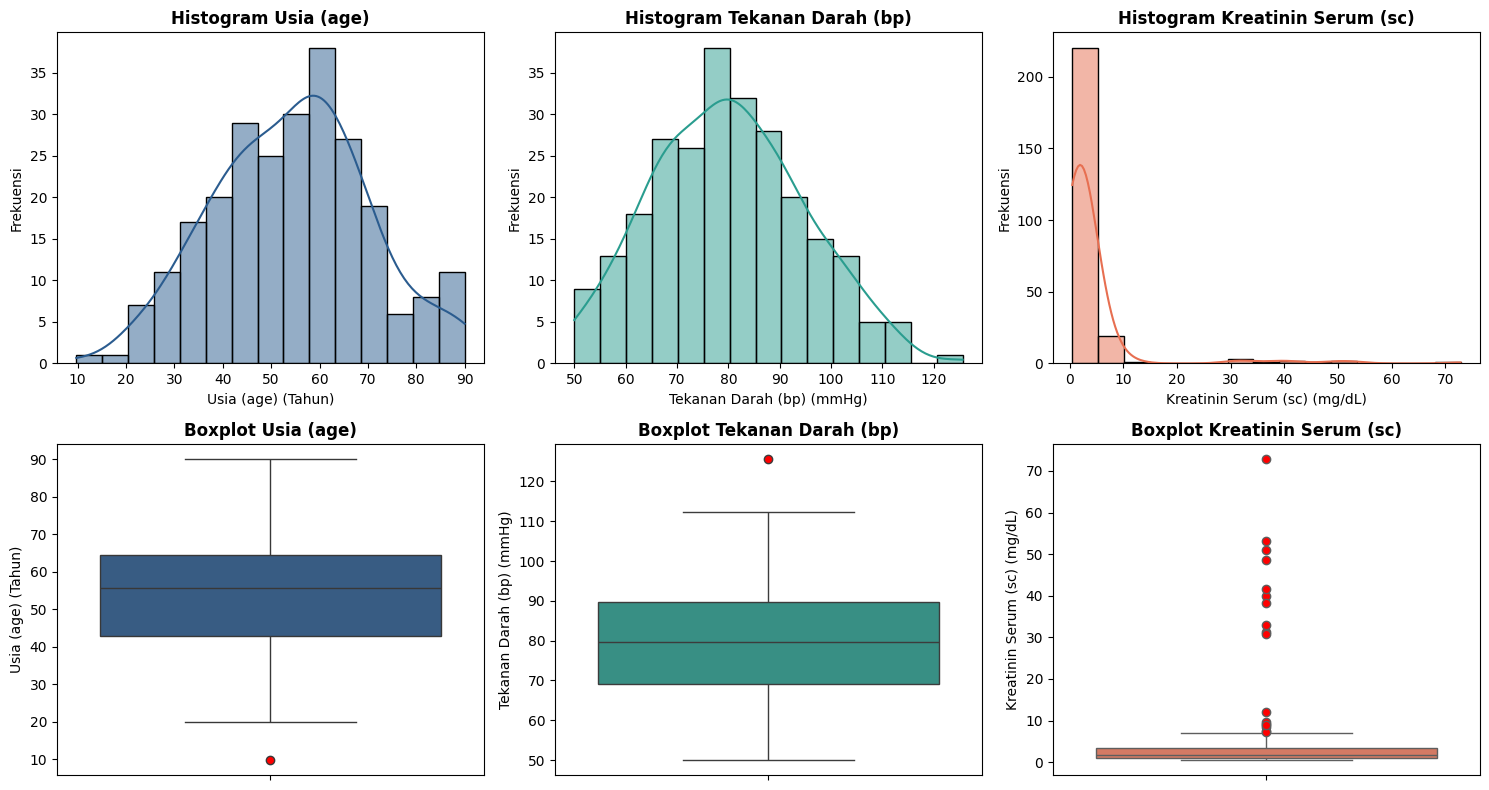


=== HASIL UJI REGRESI (UJI t & UJI F) ===
                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     2.122
Date:                Tue, 06 Oct 2026   Prob (F-statistic):              0.122
Time:                        13:58:46   Log-Likelihood:                -894.09
No. Observations:                 250   AIC:                             1794.
Df Residuals:                     247   BIC:                             1805.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# 1. SETUP DATA (250 Pasien)
np.random.seed(42)
n_samples = 250

age_data = np.clip(np.random.normal(loc=54.56, scale=17.11, size=n_samples), 2, 90)
bp_data = np.clip(np.random.normal(loc=79.64, scale=14.93, size=n_samples), 50, 180)

sc_base = np.random.exponential(scale=2.0, size=n_samples) + 0.5
sc_outliers = np.random.uniform(low=15, high=76, size=10)
sc_indices = np.random.choice(n_samples, size=10, replace=False)
sc_base[sc_indices] = sc_outliers
sc_data = sc_base

df = pd.DataFrame({'age': age_data, 'bp': bp_data, 'sc': sc_data})

# =============================================================================
# POIN 1: STATISTIKA DESKRIPTIF LENGKAP (Sesuai Permintaan Dosen)
# =============================================================================
def get_full_stats(data):
    mode_val = stats.mode(data, keepdims=True).mode[0]
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    return pd.Series({
        'n': len(data),
        'Mean': np.mean(data),
        'Median': np.median(data),
        'Modus': mode_val,
        'Std Dev': np.std(data, ddof=1),
        'Varian': np.var(data, ddof=1),
        'Range': np.ptp(data),
        'Min': np.min(data),
        'Max': np.max(data),
        'Q1 (25%)': q1,
        'Q3 (75%)': q3
    })

full_desc_stats = df.apply(get_full_stats).T
print("=== STATISTIKA DESKRIPTIF LENGKAP ===")
print(full_desc_stats.round(2))

# =============================================================================
# POIN 2: VISUALISASI (HISTOGRAM & BOXPLOT)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['#2b5c8f', '#2a9d8f', '#e76f51']
variables = ['age', 'bp', 'sc']
titles = ['Usia (age)', 'Tekanan Darah (bp)', 'Kreatinin Serum (sc)']
units = ['Tahun', 'mmHg', 'mg/dL']

for i, var in enumerate(variables):
    sns.histplot(df[var], kde=True, ax=axes[0, i], color=colors[i], bins=15)
    axes[0, i].set_title(f'Histogram {titles[i]}', fontweight='bold')
    axes[0, i].set_xlabel(f'{titles[i]} ({units[i]})')
    axes[0, i].set_ylabel('Frekuensi')

    sns.boxplot(y=df[var], ax=axes[1, i], color=colors[i],
                flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
    axes[1, i].set_title(f'Boxplot {titles[i]}', fontweight='bold')
    axes[1, i].set_ylabel(f'{titles[i]} ({units[i]})')

plt.tight_layout()
plt.show()

# =============================================================================
# POIN 3: UJI PENGARUH REGRESI (UJI t & UJI F)
# Variabel Bebas (X): Usia (age), Tekanan Darah (bp)
# Variabel Terikat (Y): Kreatinin Serum (sc)
# =============================================================================
X = df[['age', 'bp']]
Y = df['sc']
X_const = sm.add_constant(X)

model = sm.OLS(Y, X_const).fit()

print("\n=== HASIL UJI REGRESI (UJI t & UJI F) ===")
print(model.summary())